# Veri Bilimi Eğitimi


## Veri Görselleştirme

Amaç:
  1. Veri setindeki farklı değişkenleri uygun grafik türüyle görselleştirmek
  2. Grafikler üzerinden zaman değişimi, ilişki, karşılaştırma ve dağılım yapısını incelemek

Adımlar:
  1. Veri setini yüklemek
  2. Line plot ile zaman içindeki değişimi görselleştirmek
  3. Scatter plot ile iki sayısal değişken arasındaki ilişkiyi görselleştirmek
  4. Bar plot ile karşılaştırmalı görselleştirme yapmak
  5. Histogram ile sayısal dağılım görselleştirmek
  6. Box plot ile dağılım ve aykırı değer tespiti

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme()

In [ ]:
# 1. veri setini yükle
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


In [ ]:
# 2. line plot ile zaman içindeki değişimi görselleştirelim
# siparis tarihini date time a çevirelim
df["siparis_tarihi"] = pd.to_datetime(df["siparis_tarihi"])
df["siparis_ayi"] = df["siparis_tarihi"].dt.month
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


In [ ]:
aylik_toplam_tutar = df.groupby("siparis_ayi")["toplam_tutar"].sum().reset_index()
aylik_toplam_tutar

,siparis_ayi,toplam_tutar
0,1,69297.43
1,2,70064.13
2,3,73573.70
3,4,68903.73
4,5,93356.00
5,6,82688.56
6,7,68909.32
7,8,58676.79
8,9,81345.42
9,10,61096.86


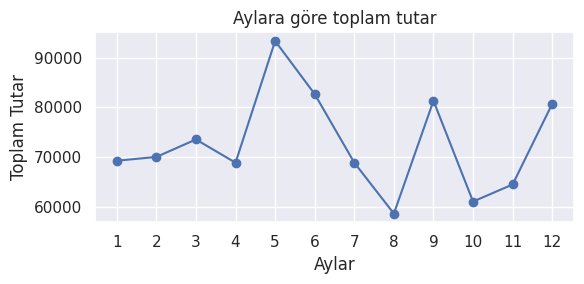

In [ ]:
plt.figure(figsize = (6,3))
plt.plot(aylik_toplam_tutar["siparis_ayi"], aylik_toplam_tutar["toplam_tutar"], marker = "o") # line plot
plt.title("Aylara göre toplam tutar")
plt.xlabel("Aylar")
plt.ylabel("Toplam Tutar")
plt.xticks(aylik_toplam_tutar["siparis_ayi"])
plt.tight_layout()
plt.show()

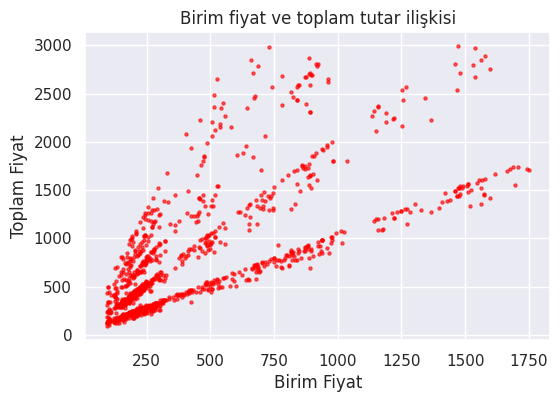

In [ ]:
# 3. scatter plot ile iki sayısal değişken arasındaki ilişkiyi görselleştirelim
plt.figure(figsize = (6,4))
plt.scatter(df["birim_fiyat"], df["toplam_tutar"], alpha = 0.6, color = "red", s = 5)
plt.title("Birim fiyat ve toplam tutar ilişkisi")
plt.xlabel("Birim Fiyat")
plt.ylabel("Toplam Fiyat")
plt.show()

In [ ]:
# 4. bar plot ile karşılaştırmalı görselleştirme
# kategoriye göre toplam tutarı toplayıp bar plot ile görselleştirme
kategori_toplam_tutar = (
    df.groupby("kategori")["toplam_tutar"]
    .sum()
    .sort_values(ascending = False)
    .reset_index()
)
kategori_toplam_tutar

,kategori,toplam_tutar
0,Elektronik,219801.14
1,Spor,196999.01
2,Kozmetik,150382.33
3,Ev Yaşam,142848.20
4,Kitap,115483.45
5,Ofis,47665.10


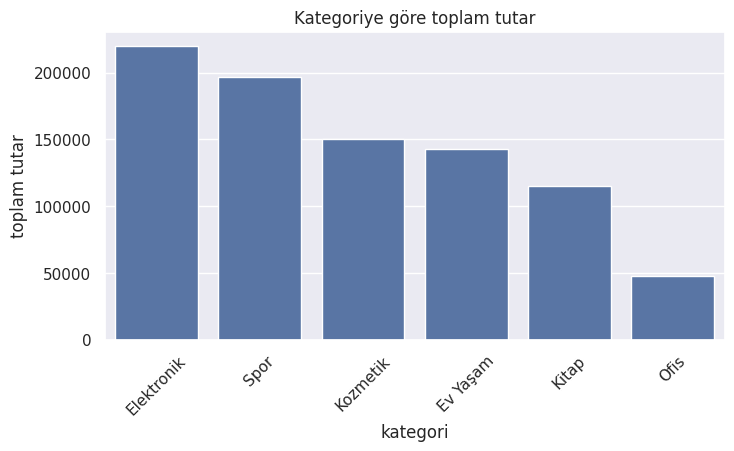

In [ ]:
plt.figure(figsize = (8,4))
sns.barplot(data = kategori_toplam_tutar, x = "kategori", y = "toplam_tutar")
plt.title("Kategoriye göre toplam tutar")
plt.xlabel("kategori")
plt.ylabel("toplam tutar")
plt.xticks(rotation = 45)
plt.show()

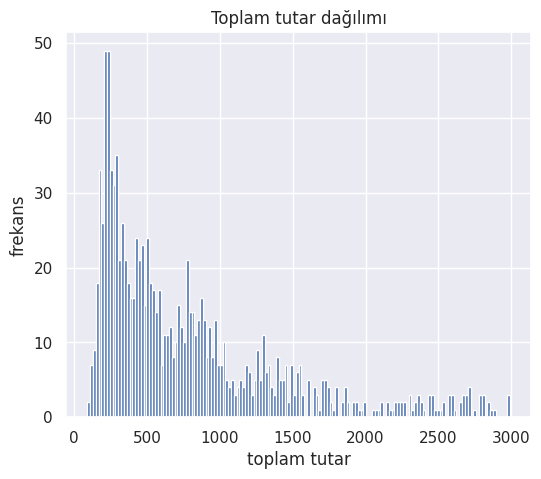

In [ ]:
# 5. histogram ile sayısal dağılım görselleştirme
plt.figure(figsize = (6,5))
plt.hist(df["toplam_tutar"], bins = 150)
plt.title("Toplam tutar dağılımı")
plt.xlabel("toplam tutar")
plt.ylabel("frekans")
plt.show()

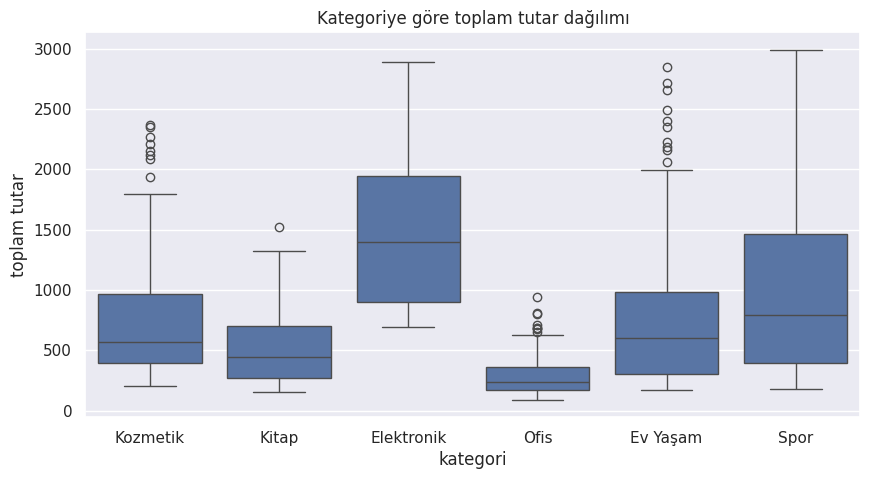

In [ ]:
# 6. box plot ile dağılım ve outlier tespiti
plt.figure(figsize = (10,5))
sns.boxplot(data = df, x = "kategori", y = "toplam_tutar")
plt.xlabel("kategori")
plt.ylabel("toplam tutar")
plt.title("Kategoriye göre toplam tutar dağılımı")
plt.show()